In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_sms = pd.read_csv(r"C:\Users\lohar\OneDrive\Documents\DA udemy\DS_ML_project\SMSspam2.csv", encoding="latin-1")

In [5]:
df_sms.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df_sms.shape

(5572, 5)

In [7]:
df_sms.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [8]:
df_sms = df_sms[['v1', 'v2']]

df_sms.columns = ['label', 'message']

In [9]:
df_sms.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
df_sms.isnull().sum()

label      0
message    0
dtype: int64

In [11]:
df_sms.duplicated().sum()

np.int64(403)

In [12]:
df_sms = df_sms.drop_duplicates().reset_index(drop=True)

In [13]:
df_sms['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

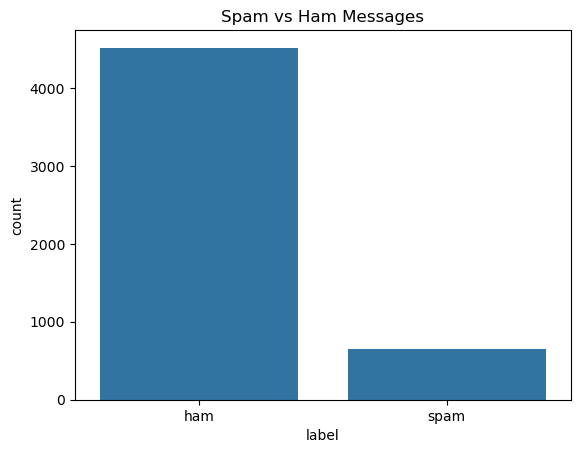

In [14]:
sns.countplot(data=df_sms, x='label')

plt.title('Spam vs Ham Messages')
plt.show()

In [15]:
df_sms['target'] = df_sms['label'].map({
    'ham': 0,
    'spam': 1
})

In [16]:
df_sms[['label', 'target']].head()

,label,target
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


In [17]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [18]:
df_sms['clean_message'] = df_sms['message'].apply(clean_text)

In [19]:
df_sms[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [20]:
df_sms['tokens'] = df_sms['clean_message'].apply(
    lambda x: x.split()
)

In [21]:
df_sms[['clean_message', 'tokens']].head()

,clean_message,tokens
0,go until jurong point crazy available only in ...,"[go, until, jurong, point, crazy, available, o..."
1,ok lar joking wif u oni,"[ok, lar, joking, wif, u, oni]"
2,free entry in a wkly comp to win fa cup final ...,"[free, entry, in, a, wkly, comp, to, win, fa, ..."
3,u dun say so early hor u c already then say,"[u, dun, say, so, early, hor, u, c, already, t..."
4,nah i dont think he goes to usf he lives aroun...,"[nah, i, dont, think, he, goes, to, usf, he, l..."


In [22]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lohar\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [23]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [24]:
def remove_stopwords(tokens):
    return [
        word for word in tokens
        if word not in stop_words
    ]

In [25]:
df_sms['filtered_tokens'] = df_sms['tokens'].apply(
    remove_stopwords
)

In [26]:
df_sms['processed_text'] = df_sms['filtered_tokens'].apply(
    lambda x: ' '.join(x)
)

In [27]:
from sklearn.model_selection import train_test_split

X = df_sms['processed_text']
y = df_sms['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [29]:
tfidf = TfidfVectorizer(
    max_features=5000
)

In [31]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [32]:
from sklearn.linear_model import LogisticRegression

sms_model = LogisticRegression(max_iter=1000)

sms_model.fit(
    X_train_tfidf,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [33]:
sms_pred = sms_model.predict(X_test_tfidf)

In [34]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        sms_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       903
           1       0.99      0.64      0.78       131

    accuracy                           0.95      1034
   macro avg       0.97      0.82      0.88      1034
weighted avg       0.96      0.95      0.95      1034



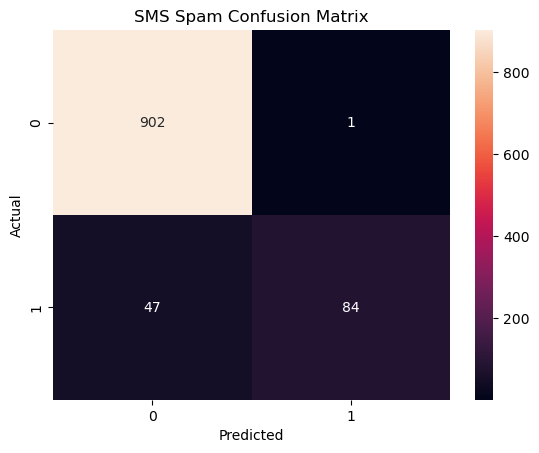

In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    sms_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SMS Spam Confusion Matrix')
plt.show()

In [36]:
message = [
    "Congratulations! You have won a free prize. Click now!"
]

In [37]:
message_tfidf = tfidf.transform(message)

In [38]:
sms_model.predict(message_tfidf)

array([1])

In [39]:
sms_model.predict_proba(message_tfidf)

array([[0.36044989, 0.63955011]])